# The MEWMA Control Chart — A Beginner's Guide

This notebook builds up the **Multivariate Exponentially Weighted Moving Average (MEWMA) control chart** from scratch. It assumes you are comfortable with the univariate `EWMA_Control_Chart_Tutorial.ipynb` in this repository — we lean on the same statistic, the same Case K notation (known in-control parameters), and the same Monte Carlo mindset, and simply promote everything from scalars to vectors and matrices.

## 1.1 From one quality characteristic to many

Real processes are rarely monitored on a single measurement. A machined part might have both a diameter and a length; a chemical process might report the concentration of several correlated compounds at once. Call these $p$ quality characteristics, measured together as a vector

$$
\mathbf{X}_i = (X_{i1}, X_{i2}, \dots, X_{ip})', \qquad i = 1, 2, 3, \dots
$$

The tempting shortcut is to just run $p$ separate univariate control charts, one per characteristic. This has two serious problems:

1. **Inflated false-alarm rate.** If each of $p$ independent charts has in-control $ARL_0 \approx 370$, the chance that *at least one* of them false-alarms on a given point is much higher than the chance for a single chart — running more charts means more chances for a false alarm, even though the process hasn't changed at all.
2. **Blindness to correlation.** Separate charts only ever look at *one axis at a time*. If the characteristics are correlated — as they almost always are, because they come from the same underlying physical process — a shift that breaks the usual *relationship* between them can be completely invisible to charts that only ever look at one variable's own history.

## 1.2 An analogy: two dials that normally move together

Picture two gauges on a machine that, under normal operation, rise and fall together — think of engine temperature and pressure. If temperature suddenly rises while pressure *drops*, that is deeply suspicious, even if both readings are still comfortably inside their own individual "normal" range. A chart that watches the two dials **jointly** can catch this immediately; two separate dial-watchers, each only remembering their own dial's history, cannot — from where each of them is standing, nothing looks wrong.

The **MEWMA chart** (Lowry, Woodall, Champ & Rigdon, 1992) is exactly this joint watcher. It extends the univariate EWMA statistic to vectors, and collapses the result into a single number — the analogue of "how far is this point from where it should be, accounting for how the variables normally relate to each other?" — that is monitored with a single control limit.

## 1.3 Roadmap

1. Build intuition for *why* joint monitoring matters, via the geometric idea of Mahalanobis distance.
2. Define the MEWMA statistic as the natural vector generalisation of the univariate recursion.
3. Derive its covariance matrix and the Hotelling-type $T^2$ statistic used to monitor it, and discuss why choosing its control limit needs simulation, just like the univariate ARL story.
4. Simulate an in-control bivariate process and build our first MEWMA chart.
5. Inject a shift and show, concretely, that **direction matters as much as size**: two shifts of identical per-variable magnitude can be almost invisible or blindingly obvious to the MEWMA chart, depending only on how they align with the correlation between variables.
6. Tune the control limit and quantify chart performance with Monte Carlo ARL studies, mirroring Section 9 of the univariate notebook.

## 2. Setup

Same core toolset as the univariate notebook (`numpy`, `pandas`, `matplotlib`), plus `scipy.stats.chi2` for the chi-square distribution that shows up when we standardise a multivariate normal vector by its own covariance matrix. We reuse the same random seed for continuity across notebooks in this repository.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

# Fixed seed -> reproducible simulations (same seed used throughout this repo)
RNG = np.random.default_rng(seed=795)

# A clean, readable default style for all plots in this notebook
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# Colour palette used consistently throughout
COL_V1     = "#4C72B0"   # variable 1 (X1)
COL_V2     = "#DD8452"   # variable 2 (X2)
COL_CL     = "#55A868"   # center line
COL_LIMITS = "#C44E52"   # control limits / reference boundaries
COL_OOC    = "#C44E52"   # out-of-control points


## 3. Why monitor jointly? Mahalanobis distance

Suppose $p=2$ correlated quality characteristics are, when the process is in control, jointly normal:

$$
\mathbf{X}_i \sim N_p(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}), \qquad
\boldsymbol{\Sigma} = \begin{pmatrix}\sigma_1^2 & \sigma_{12} \\ \sigma_{12} & \sigma_2^2\end{pmatrix}
$$

The diagonal of $\boldsymbol{\Sigma}$ holds the individual variances; the off-diagonal holds the covariance that ties the two variables together (equivalently, the correlation $\rho = \sigma_{12}/(\sigma_1\sigma_2)$).

### 3.1 Ordinary (Euclidean) distance is the wrong ruler

A point $\mathbf{x}$'s ordinary distance from the target $\boldsymbol{\mu}_0$ is $\lVert \mathbf{x}-\boldsymbol{\mu}_0 \rVert$. This treats all directions as equally "unusual," which is wrong whenever the variables are correlated: moving 2 units in the direction the variables *naturally move together* is far more plausible than moving 2 units in the direction that **breaks** that relationship.

### 3.2 Mahalanobis distance: a ruler that respects correlation

The **Mahalanobis distance** fixes this by rescaling distance using the inverse covariance matrix:

$$
D(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol{\mu}_0)' \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu}_0)}
$$

Points with the same Mahalanobis distance from $\boldsymbol{\mu}_0$ trace out an **ellipse** (not a circle) — stretched along the direction the data naturally vary in, and squeezed along the direction that goes against the correlation. This ellipse is the natural multivariate generalisation of the univariate "$\pm L\sigma$" interval.

### 3.3 The rectangle trap

If instead we run two *separate* univariate charts (one per variable, each with its own $\pm 3\sigma$ limits), the region they jointly call "in control" is a **rectangle**: the intersection of the two individual intervals. When the variables are correlated, this rectangle is a poor stand-in for the true elliptical region — its corners poke out far beyond the ellipse in the "correlation-breaking" directions, silently accepting points that are, in truth, extreme. The figure below makes this concrete.

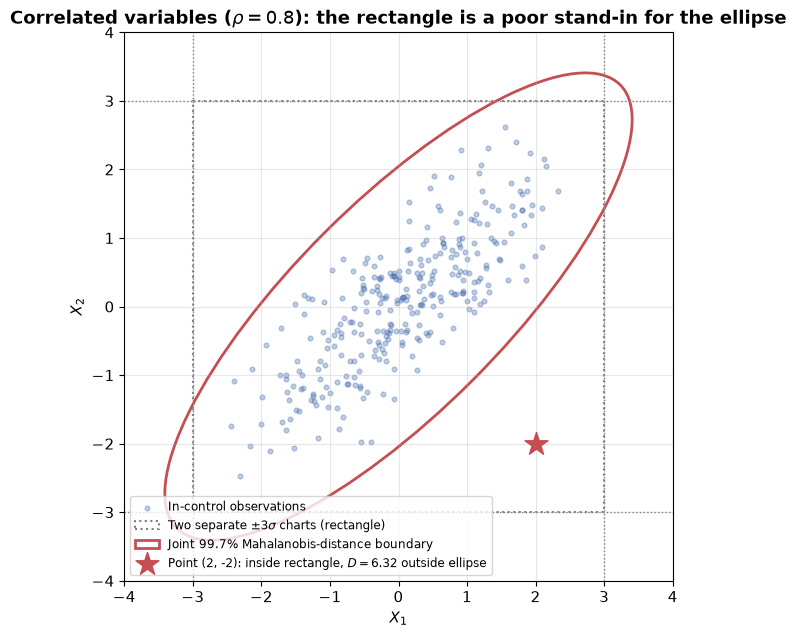

Sneaky point (2, -2) is within +/-3 on BOTH axes individually,
but its Mahalanobis distance is D=6.32, far beyond the 99.7% ellipse radius of 3.41.


In [2]:
mu0 = np.array([0.0, 0.0])
RHO = 0.8
Sigma = np.array([[1.0, RHO],
                   [RHO, 1.0]])

# A large in-control cloud, purely for the picture
X_demo = RNG.multivariate_normal(mu0, Sigma, size=300)

# A "sneaky" point: well within +/-3 on EACH axis individually...
sneaky_point = np.array([2.0, -2.0])
# ...but far outside the joint 99.7% Mahalanobis-distance ellipse:
Sigma_inv = np.linalg.inv(Sigma)
d_sneaky = np.sqrt(sneaky_point @ Sigma_inv @ sneaky_point)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(X_demo[:, 0], X_demo[:, 1], s=12, alpha=0.35, color=COL_V1, label="In-control observations")

# Univariate +/-3sigma rectangle
for lim in (-3, 3):
    ax.axvline(lim, color="gray", linestyle=":", linewidth=1)
    ax.axhline(lim, color="gray", linestyle=":", linewidth=1)
ax.add_patch(plt.Rectangle((-3, -3), 6, 6, fill=False, edgecolor="gray", linestyle=":",
                            linewidth=1.5, label=r"Two separate $\pm3\sigma$ charts (rectangle)"))

# 99.7% Mahalanobis-distance ellipse
eigvals, eigvecs = np.linalg.eigh(Sigma)
order = eigvals.argsort()[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
radius = np.sqrt(chi2.ppf(0.997, df=2))
width, height = 2 * radius * np.sqrt(eigvals)
ellipse = Ellipse(xy=mu0, width=width, height=height, angle=angle, edgecolor=COL_LIMITS,
                   facecolor="none", linewidth=2, label="Joint 99.7% Mahalanobis-distance boundary")
ax.add_patch(ellipse)

ax.scatter(*sneaky_point, color=COL_OOC, marker="*", s=300, zorder=5,
           label=fr"Point (2, -2): inside rectangle, $D={d_sneaky:.2f}$ outside ellipse")

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_xlabel("$X_1$"); ax.set_ylabel("$X_2$")
ax.set_title(fr"Correlated variables ($\rho={RHO}$): the rectangle is a poor stand-in for the ellipse")
ax.legend(loc="lower left", fontsize=8.5)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"Sneaky point (2, -2) is within +/-3 on BOTH axes individually,")
print(f"but its Mahalanobis distance is D={d_sneaky:.2f}, far beyond the "
      f"99.7% ellipse radius of {radius:.2f}.")


## 4. The MEWMA statistic

Let $\mathbf{X}_1, \mathbf{X}_2, \dots$ be the sequence of $p$-dimensional observations, with $\mathbf{X}_i \sim N_p(\boldsymbol{\mu}_0, \boldsymbol{\Sigma})$ independently when the process is in control. The **MEWMA statistic** is the direct vector generalisation of the univariate recursion:

$$
\mathbf{Z}_i = \boldsymbol{\Lambda}\, \mathbf{X}_i + (\mathbf{I}-\boldsymbol{\Lambda})\, \mathbf{Z}_{i-1}, \qquad \mathbf{Z}_0 = \boldsymbol{\mu}_0
$$

where $\boldsymbol{\Lambda} = \mathrm{diag}(\lambda_1, \dots, \lambda_p)$ collects one smoothing constant per variable, and $\mathbf{I}$ is the $p\times p$ identity matrix.

### 4.1 The equal-smoothing-constant case

Allowing a different $\lambda_j$ per variable is possible but adds little beginner-friendly intuition and complicates the covariance derivation below (only because it stops $\boldsymbol{\Lambda}$ from commuting with $\boldsymbol{\Sigma}$). Following Lowry et al. (1992), and matching the entire rest of this notebook, we use a single shared smoothing constant $\lambda_1=\dots=\lambda_p=\lambda$, so $\boldsymbol{\Lambda}=\lambda\mathbf{I}$ and the recursion collapses to

$$
\mathbf{Z}_i = \lambda\, \mathbf{X}_i + (1-\lambda)\, \mathbf{Z}_{i-1}
$$

which is **exactly the univariate EWMA recursion from Section 3 of the other notebook, applied component-wise and simultaneously to every variable**. Unrolling it gives the same exponentially-decaying weighted sum as before, just with vectors in place of scalars:

$$
\mathbf{Z}_i = \lambda \sum_{j=0}^{i-1} (1-\lambda)^{j}\, \mathbf{X}_{i-j} \; + \; (1-\lambda)^{i}\, \boldsymbol{\mu}_0
$$

So every intuition we built about $\lambda$ in the univariate notebook — small $\lambda$ gives long memory and smooth behaviour, $\lambda \to 1$ recovers the raw (Shewhart-like) data — carries over unchanged, just applied jointly to the whole vector.

## 5. Covariance, the $T^2$ statistic, and the control limit

### 5.1 Mean

Since $\mathbf{Z}_i$ is a weighted combination of the $\mathbf{X}_i$'s (and $\boldsymbol{\mu}_0$), and $E[\mathbf{X}_i]=\boldsymbol{\mu}_0$, we get $E[\mathbf{Z}_i] = \boldsymbol{\mu}_0$ for all $i$ — the target is the center of the chart, exactly as before.

### 5.2 Exact and asymptotic covariance

Because $\boldsymbol{\Lambda}=\lambda\mathbf{I}$ is a **scalar multiple of the identity**, it commutes with $\boldsymbol{\Sigma}$, and the same finite-geometric-sum argument used for the univariate variance goes through unchanged, just with $\boldsymbol{\Sigma}$ in place of $\sigma^2$:

$$
\boldsymbol{\Sigma}_{\mathbf{Z}_i} = \left(\frac{\lambda}{2-\lambda}\right)\Big[1-(1-\lambda)^{2i}\Big]\, \boldsymbol{\Sigma}
$$

and as $i\to\infty$ the bracketed term $\to 1$, giving the constant **asymptotic covariance**

$$
\boldsymbol{\Sigma}_{\mathbf{Z}} = \left(\frac{\lambda}{2-\lambda}\right) \boldsymbol{\Sigma}
$$

Exactly as in the univariate case, the exact covariance starts small and inflates toward this steady-state value as more points arrive.

### 5.3 A practical note: which covariance to standardise by

Because $\boldsymbol{\Sigma}_{\mathbf{Z}_i}$ is small for early $i$ (especially for small $\lambda$), standardising by the *exact* covariance makes $T_i^2$ very sensitive to even tiny early fluctuations — it can flag "signals" in the first few points that have nothing to do with a genuine shift, purely because the denominator hasn't caught up yet. To keep the chart's behaviour tied to genuine shifts rather than this early-time artifact, the rest of this notebook standardises $T_i^2$ using the **asymptotic** covariance $\boldsymbol{\Sigma}_{\mathbf{Z}}$ throughout (not just for the ARL study in Section 9) — the same steady-state-limits convention the univariate notebook adopts for its ARL work, applied here a little more broadly.

### 5.4 Collapsing the vector into one number: the $T^2$ statistic

A vector chart can't be plotted directly the way a scalar can. Instead, MEWMA collapses $\mathbf{Z}_i$ into a single non-negative number using exactly the Mahalanobis-distance idea from Section 3, but measured against $\mathbf{Z}_i$'s **own** covariance:

$$
T_i^2 = (\mathbf{Z}_i - \boldsymbol{\mu}_0)'\, \boldsymbol{\Sigma}_{\mathbf{Z}_i}^{-1}\, (\mathbf{Z}_i - \boldsymbol{\mu}_0)
$$

Because $T_i^2 \geq 0$ always, and a value of $0$ means "exactly on target," there is only **one** control limit to worry about — an **upper** control limit $h$. The chart signals when

$$
T_i^2 > h
$$

### 5.5 Why $h$ needs simulation, just like the univariate ARL

Here's a subtlety worth sitting with. If $\mathbf{X}_i$ really are exactly multivariate normal, then for any *fixed* time $i$, $\mathbf{Z}_i$ is itself an exact linear combination of jointly normal vectors, so it is exactly $N_p(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_{\mathbf{Z}_i})$ — and standardising a normal vector by its own true covariance gives, at that single fixed point in time,

$$
T_i^2 \sim \chi^2_p \qquad \text{(exactly, at each individual } i\text{)}
$$

This looks like it hands us $h$ for free: just pick the $(1-\alpha)$ quantile of $\chi^2_p$ for some small per-point false-alarm rate $\alpha$. **But this quantile does not translate directly into the in-control $ARL_0$ we actually care about.** The reason is the same one that made the univariate ARL story interesting: consecutive $\mathbf{Z}_i$'s are heavily autocorrelated (each one shares almost all of its "memory" with the previous one), so the sequence of exceedance events across time is nothing like a sequence of independent coin flips at rate $\alpha$. A per-point chi-square quantile tells us about *one* point in isolation; $ARL_0$ is a statement about the *whole sequence*.

Just like Section 9 of the univariate notebook, there is no simple closed form for $ARL_0$ here — so, exactly as before, **we find $h$ by Monte Carlo simulation** (this is also how the published MEWMA design tables in Lowry, Woodall, Champ & Rigdon, 1992, were built): simulate many long in-control runs at a candidate $h$, measure the resulting $ARL_0$, and adjust $h$ until $ARL_0$ hits the target. We'll do exactly this in Section 9, after first building some intuition for the chart with a reasonable starting guess.

## 6. Helper functions

Three building blocks, directly paralleling `ewma_statistic` and `ewma_limits` from the univariate notebook:

* `mewma_statistic` — the vector recursion from Section 4.
* `mewma_cov` — the exact (time-varying) or asymptotic covariance matrices from Section 5.2, one $p\times p$ matrix per time point.
* `hotelling_t2` — the $T_i^2$ statistic from Section 5.4.

In [3]:
def mewma_statistic(X, mu0, lam):
    '''Vector MEWMA recursion. X: (m, p) array of observations. mu0: (p,) mean vector.
    Returns Z: (m, p) array of MEWMA vectors Z_1, ..., Z_m.'''
    m, p = X.shape
    Z = np.empty((m, p))
    z_prev = np.asarray(mu0, dtype=float).copy()
    for i in range(m):
        z_prev = lam * X[i] + (1 - lam) * z_prev
        Z[i] = z_prev
    return Z


def mewma_cov(Sigma, lam, m, exact=True):
    '''Return Sigma_{Z_i} for i=1..m as an (m, p, p) array.
    If exact=False, returns the constant asymptotic covariance broadcast to length m.'''
    i = np.arange(1, m + 1)
    factor = lam / (2 - lam)
    if exact:
        scale = factor * (1 - (1 - lam) ** (2 * i))
    else:
        scale = np.full(m, factor)
    return scale[:, None, None] * Sigma[None, :, :]


def hotelling_t2(Z, mu0, Sigma_Z_seq):
    '''T_i^2, the Mahalanobis distance of each MEWMA vector from mu0 using its own covariance.'''
    diff = Z - mu0
    T2 = np.empty(len(Z))
    for i in range(len(Z)):
        T2[i] = diff[i] @ np.linalg.inv(Sigma_Z_seq[i]) @ diff[i]
    return T2


## 7. Simulating an in-control bivariate process and building the MEWMA chart

We use $p=2$ correlated variables ($\rho=0.8$, the same $\boldsymbol{\Sigma}$ as Section 3's illustration) and $\lambda=0.1$ — a common choice in the MEWMA literature. As a starting point for the control limit, we use the chi-square-quantile guess from Section 5.5 (we will see in Section 9 that it is only a rough starting point, not the final answer). Following the note in Section 5.3, $T_i^2$ is standardised using the asymptotic covariance throughout.

We plot the two individual-variable EWMA charts alongside the joint $T^2$ chart, so the relationship between them is visible from the start.

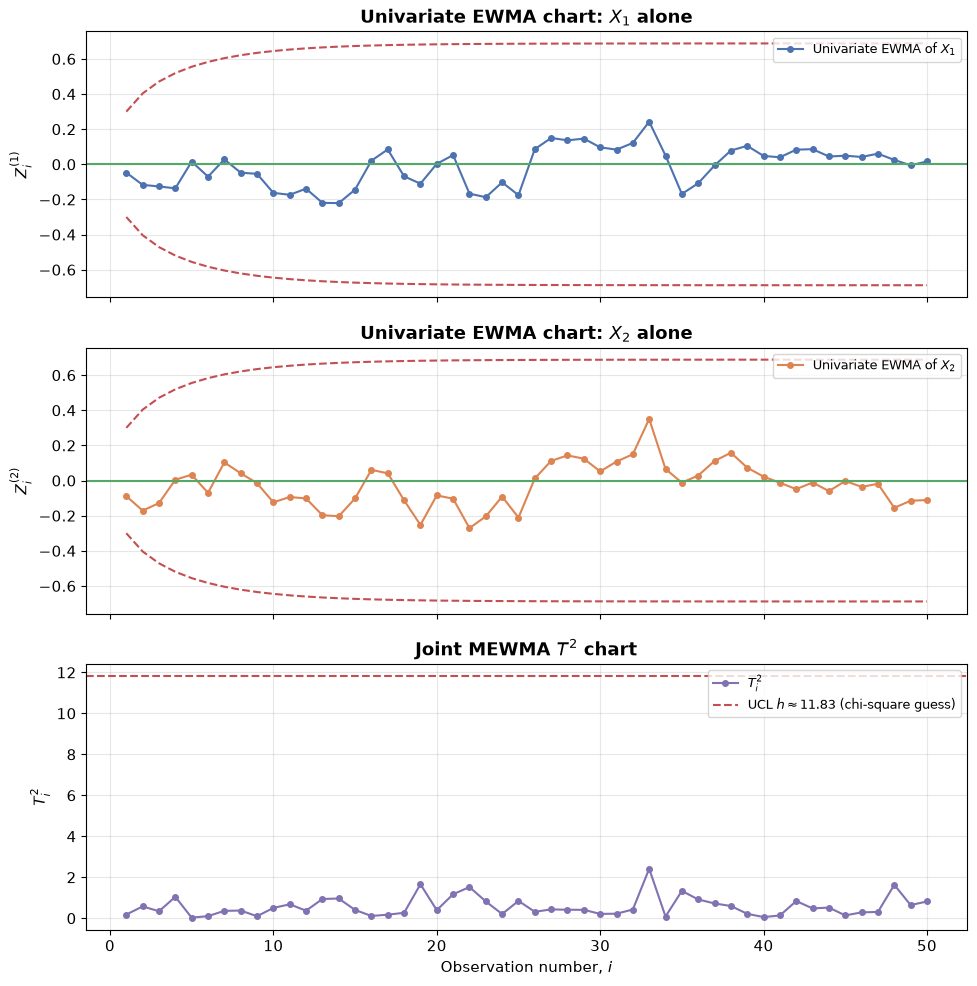

In [4]:
lam = 0.1
p = 2
m = 50
idx = np.arange(1, m + 1)

h_guess = chi2.ppf(0.9973, df=p)  # naive per-point chi-square guess; refined via simulation in Section 9

X_ic = RNG.multivariate_normal(mu0, Sigma, size=m)
Z_ic = mewma_statistic(X_ic, mu0, lam)
SigmaZ_asym_ic = mewma_cov(Sigma, lam, m, exact=False)  # asymptotic, per the note in Section 5.3
T2_ic = hotelling_t2(Z_ic, mu0, SigmaZ_asym_ic)

# Univariate EWMA on each column separately, for comparison (own variance = diagonal of Sigma)
def ewma_statistic_uni(x, mu0, lam):
    z = np.empty(len(x))
    z_prev = mu0
    for i, xi in enumerate(x):
        z_prev = lam * xi + (1 - lam) * z_prev
        z[i] = z_prev
    return z

def ewma_limits_uni(mu0, sigma, lam, L, m):
    i = np.arange(1, m + 1)
    factor = lam / (2 - lam)
    width = L * sigma * np.sqrt(factor * (1 - (1 - lam) ** (2 * i)))
    return mu0 + width, mu0 - width

L_uni = 3.0
z1 = ewma_statistic_uni(X_ic[:, 0], mu0[0], lam)
z2 = ewma_statistic_uni(X_ic[:, 1], mu0[1], lam)
ucl1, lcl1 = ewma_limits_uni(mu0[0], np.sqrt(Sigma[0, 0]), lam, L_uni, m)
ucl2, lcl2 = ewma_limits_uni(mu0[1], np.sqrt(Sigma[1, 1]), lam, L_uni, m)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax = axes[0]
ax.plot(idx, z1, marker="o", markersize=4, color=COL_V1, label="Univariate EWMA of $X_1$")
ax.axhline(mu0[0], color=COL_CL)
ax.plot(idx, ucl1, color=COL_LIMITS, linestyle="--"); ax.plot(idx, lcl1, color=COL_LIMITS, linestyle="--")
ax.set_ylabel("$Z_i^{(1)}$"); ax.set_title("Univariate EWMA chart: $X_1$ alone"); ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
ax.plot(idx, z2, marker="o", markersize=4, color=COL_V2, label="Univariate EWMA of $X_2$")
ax.axhline(mu0[1], color=COL_CL)
ax.plot(idx, ucl2, color=COL_LIMITS, linestyle="--"); ax.plot(idx, lcl2, color=COL_LIMITS, linestyle="--")
ax.set_ylabel("$Z_i^{(2)}$"); ax.set_title("Univariate EWMA chart: $X_2$ alone"); ax.legend(loc="upper right", fontsize=9)

ax = axes[2]
ax.plot(idx, T2_ic, marker="o", markersize=4, color="#8172B2", label="$T_i^2$")
ax.axhline(h_guess, color=COL_LIMITS, linestyle="--", label=fr"UCL $h \approx {h_guess:.2f}$ (chi-square guess)")
ax.set_xlabel("Observation number, $i$"); ax.set_ylabel("$T_i^2$")
ax.set_title(r"Joint MEWMA $T^2$ chart"); ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()


## 8. Detecting a shift: why direction matters, not just magnitude

Here is the central multivariate insight this chart exists to capture. We construct **two** shift scenarios, starting at observation 26 (matching the univariate notebook's convention), each shifting both variables by the **same magnitude**, $0.75\sigma$:

* **Aligned shift**: $\boldsymbol\delta_{\text{aligned}} = (0.75,\ 0.75)\sigma$ — both variables move up together, i.e. *with* the positive correlation between them.
* **Cross shift**: $\boldsymbol\delta_{\text{cross}} = (0.75,\ -0.75)\sigma$ — one moves up, the other down, i.e. *against* the correlation.

Because a univariate EWMA chart is symmetric around its center line, its detection speed only depends on the **magnitude** of the shift in its own variable, not the sign. Since $|{+0.75}| = |{-0.75}|$, **both scenarios look statistically identical to the two separate univariate charts** — $X_1$'s chart sees the same $+0.75\sigma$ shift in both scenarios, and $X_2$'s chart sees the same $0.75\sigma$-magnitude shift (just flipped in sign) in both. If we only had the univariate charts, we would predict these two scenarios are equally (un)detectable.

The joint $T^2$ chart tells a completely different story, because it measures Mahalanobis distance, not raw magnitude: the cross shift fights the correlation structure and produces a far larger $T^2$ than the aligned shift, for identical per-variable magnitudes.

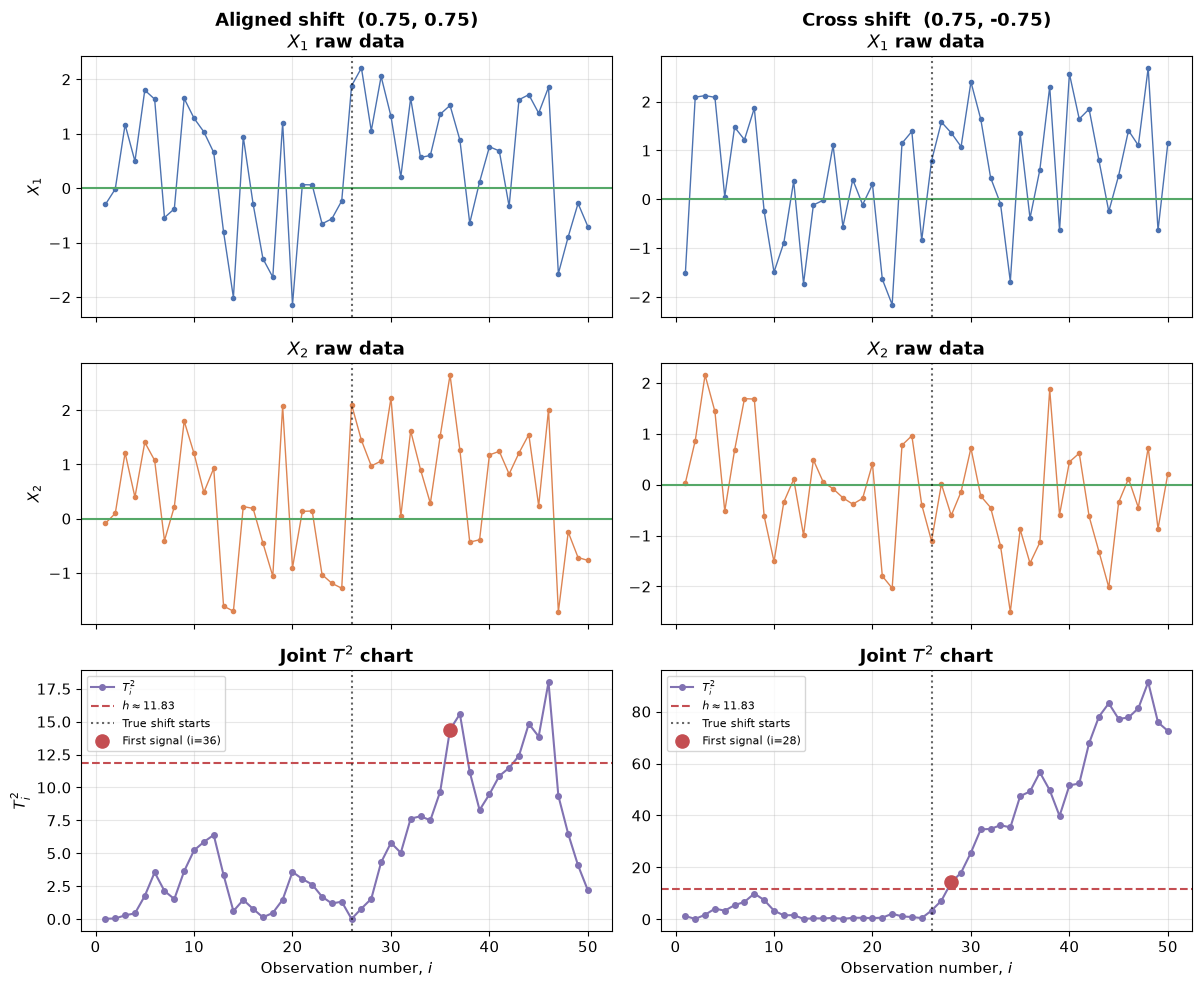

Aligned shift: T2 signalled at i=36 (10 points after the true shift began).
Cross shift: T2 signalled at i=28 (2 points after the true shift began).


In [5]:
shift_point = 25  # 0-indexed: observations 0..24 in control, 25..49 shifted
delta_aligned = np.array([0.75, 0.75])
delta_cross = np.array([0.75, -0.75])

def build_shift_scenario(delta, rng):
    X = rng.multivariate_normal(mu0, Sigma, size=m)
    X[shift_point:] += delta
    Z = mewma_statistic(X, mu0, lam)
    SigmaZ_asym = mewma_cov(Sigma, lam, m, exact=False)  # asymptotic, per the note in Section 5.3
    T2 = hotelling_t2(Z, mu0, SigmaZ_asym)
    return X, T2

rng_shift = np.random.default_rng(795)
X_aligned, T2_aligned = build_shift_scenario(delta_aligned, rng_shift)
X_cross, T2_cross = build_shift_scenario(delta_cross, rng_shift)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

for col, (name, X, T2, delta) in enumerate([
        ("Aligned shift  (0.75, 0.75)", X_aligned, T2_aligned, delta_aligned),
        ("Cross shift  (0.75, -0.75)", X_cross, T2_cross, delta_cross)]):

    ax = axes[0, col]
    ax.plot(idx, X[:, 0], marker="o", markersize=3, color=COL_V1, linewidth=1)
    ax.axhline(mu0[0], color=COL_CL)
    ax.axvline(shift_point + 1, color="black", linestyle=":", alpha=0.6)
    ax.set_title(f"{name}\n$X_1$ raw data")

    ax = axes[1, col]
    ax.plot(idx, X[:, 1], marker="o", markersize=3, color=COL_V2, linewidth=1)
    ax.axhline(mu0[1], color=COL_CL)
    ax.axvline(shift_point + 1, color="black", linestyle=":", alpha=0.6)
    ax.set_title("$X_2$ raw data")

    ax = axes[2, col]
    ax.plot(idx, T2, marker="o", markersize=4, color="#8172B2", label="$T_i^2$")
    ax.axhline(h_guess, color=COL_LIMITS, linestyle="--", label=fr"$h\approx{h_guess:.2f}$")
    ax.axvline(shift_point + 1, color="black", linestyle=":", alpha=0.6, label="True shift starts")
    ooc = np.where(T2 > h_guess)[0]
    if len(ooc):
        first = ooc[0]
        ax.scatter([idx[first]], [T2[first]], color=COL_OOC, s=90, zorder=5,
                   label=f"First signal (i={idx[first]})")
    ax.set_xlabel("Observation number, $i$")
    ax.set_title(r"Joint $T^2$ chart")
    ax.legend(loc="upper left", fontsize=8)

axes[0, 0].set_ylabel("$X_1$"); axes[1, 0].set_ylabel("$X_2$"); axes[2, 0].set_ylabel("$T_i^2$")
plt.tight_layout()
plt.show()

for name, T2 in [("Aligned", T2_aligned), ("Cross", T2_cross)]:
    ooc = np.where(T2 > h_guess)[0]
    if len(ooc):
        print(f"{name} shift: T2 signalled at i={idx[ooc[0]]} "
              f"({idx[ooc[0]] - (shift_point + 1)} points after the true shift began).")
    else:
        print(f"{name} shift: T2 did not signal within the simulated window.")


Even though $X_1$'s and $X_2$'s raw data (top two rows) look about equally "shifted" between the two columns — same magnitude, just a sign flip in $X_2$ — the joint $T^2$ chart (bottom row) reacts very differently. The cross shift, which pushes the process **against** the natural positive correlation between $X_1$ and $X_2$, produces a much larger, faster $T^2$ signal than the aligned shift, which moves **with** that correlation and is comparatively unremarkable in Mahalanobis-distance terms. This is precisely the failure mode described in Section 1: two separate univariate charts cannot see this difference at all, because neither one ever looks at the *other* variable.

## 9. Choosing the control limit $h$ via Monte Carlo (in-control ARL)

Following the reasoning in Section 5.5, we now estimate $ARL_0$ by simulation and tune $h$ to hit a target. We'll target $ARL_0 = 200$, a standard benchmark used in the MEWMA literature (analogous to the univariate notebook's $ARL_0 \approx 370$ benchmark — the exact target is a design choice, not a universal constant).

### 9.1 A faster Monte Carlo engine

The univariate notebook simulated one run length at a time in a plain Python loop — fine for a scalar recursion. Here, each step additionally involves $p\times p$ matrix algebra, which makes a naive per-run Python loop considerably slower. Instead, we simulate **all Monte Carlo replications simultaneously** using `numpy` array operations (one time-step of every replication at once), which is dramatically faster for the same number of replications. We also use the **asymptotic** covariance throughout (as in the univariate ARL study), since $\boldsymbol{\Sigma}_{\mathbf{Z}_i} \to \boldsymbol{\Sigma}_{\mathbf{Z}}$ quickly relative to typical run lengths.

In [6]:
def simulate_run_lengths_mewma(rng, mu0, Sigma, lam, h, shift, n_sims, max_len=2000):
    '''Vectorised Monte Carlo: simulate n_sims MEWMA run lengths in parallel.
    Returns an (n_sims,) array of run lengths (censored at max_len if no signal occurred).'''
    p = len(mu0)
    factor = lam / (2 - lam)
    Sigma_inv = np.linalg.inv(Sigma)
    L = np.linalg.cholesky(Sigma)
    true_mean = mu0 + shift

    Z = np.tile(np.asarray(mu0, dtype=float), (n_sims, 1))
    run_length = np.full(n_sims, max_len, dtype=int)
    active = np.ones(n_sims, dtype=bool)

    for i in range(1, max_len + 1):
        if not active.any():
            break
        noise = rng.standard_normal((n_sims, p)) @ L.T
        X = true_mean + noise
        Z = lam * X + (1 - lam) * Z
        diff = Z - mu0
        T2 = np.einsum("ij,jk,ik->i", diff, Sigma_inv, diff) / factor
        newly_signalled = active & (T2 > h)
        run_length[newly_signalled] = i
        active &= ~newly_signalled

    return run_length


def estimate_arl_mewma(rng, mu0, Sigma, lam, h, shift, n_sims=5000, max_len=2000):
    '''Monte Carlo estimate of the ARL for a given shift vector. Returns (ARL estimate, standard error).'''
    run_lengths = simulate_run_lengths_mewma(rng, mu0, Sigma, lam, h, shift, n_sims, max_len=max_len)
    return run_lengths.mean(), run_lengths.std(ddof=1) / np.sqrt(n_sims)


arl0_at_guess, se_at_guess = estimate_arl_mewma(RNG, mu0, Sigma, lam, h_guess, np.zeros(p),
                                                 n_sims=5000, max_len=2000)
print(f"Chi-square guess: h = {h_guess:.3f}  ->  estimated ARL0 = {arl0_at_guess:.1f}  (SE = {se_at_guess:.1f})")
print("Target: ARL0 = 200")
print()
print("The chi-square quantile is a per-point false-alarm guess; it does not land on the")
print("target ARL0 because of the autocorrelation discussed in Section 5.5 -- we need to search for h.")


Chi-square guess: h = 11.829  ->  estimated ARL0 = 730.3  (SE = 8.5)
Target: ARL0 = 200

The chi-square quantile is a per-point false-alarm guess; it does not land on the
target ARL0 because of the autocorrelation discussed in Section 5.5 -- we need to search for h.


In [7]:
# Bisection search for h that achieves the target in-control ARL0
target_arl0 = 200.0
lo, hi = chi2.ppf(0.80, df=p), chi2.ppf(0.99999, df=p)

search_log = []
for iteration in range(10):
    mid = 0.5 * (lo + hi)
    arl0_mid, se_mid = estimate_arl_mewma(RNG, mu0, Sigma, lam, mid, np.zeros(p), n_sims=3000, max_len=2000)
    search_log.append((iteration, mid, arl0_mid, se_mid))
    if arl0_mid < target_arl0:
        lo = mid
    else:
        hi = mid

search_table = pd.DataFrame(search_log, columns=["iteration", "h", "ARL0 estimate", "SE"])
display(search_table)

h_mewma = 0.5 * (lo + hi)
arl0_final, se_final = estimate_arl_mewma(RNG, mu0, Sigma, lam, h_mewma, np.zeros(p), n_sims=8000, max_len=2000)
print(f"\nTuned control limit: h = {h_mewma:.3f}")
print(f"Confirmation run: estimated ARL0 = {arl0_final:.1f}  (SE = {se_final:.1f}), target = {target_arl0:.0f}")


,iteration,h,ARL0 estimate,SE
0,0,13.122363,1073.753333,12.960556
1,1,8.170620,163.758333,2.858518
2,2,10.646491,457.817333,7.868136
3,3,9.408556,276.208000,4.912354
4,4,8.789588,218.009333,3.843532
5,5,8.480104,183.433667,3.189702
6,6,8.634846,202.469000,3.519172
7,7,8.557475,194.426333,3.426355
8,8,8.596160,197.075667,3.424010
9,9,8.615503,194.570667,3.373739



Tuned control limit: h = 8.625
Confirmation run: estimated ARL0 = 201.3  (SE = 2.1), target = 200


## 10. ARL performance: shift magnitude and direction

Using the tuned $h$ from Section 9, we now repeat the Monte Carlo ARL estimation across a grid of shift magnitudes $c$ (in units of $\sigma$), for both the aligned shift $(c, c)$ and the cross shift $(c, -c)$ from Section 8. This turns the single-run illustration from Section 8 into a full performance curve, mirroring Section 9.3 of the univariate notebook.

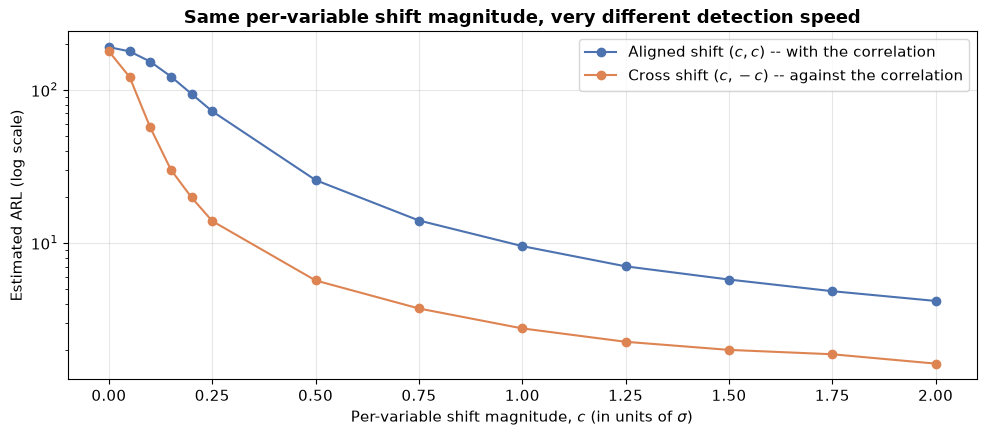

At every magnitude c > 0, the cross-direction shift is detected far faster than the
aligned shift, even though a univariate chart could never tell these two cases apart.


In [8]:
magnitudes = np.concatenate([np.arange(0.0, 0.26, 0.05), np.arange(0.5, 2.01, 0.25)])
arl_aligned = np.empty(len(magnitudes))
arl_cross = np.empty(len(magnitudes))

for k, c in enumerate(magnitudes):
    arl_aligned[k], _ = estimate_arl_mewma(RNG, mu0, Sigma, lam, h_mewma, np.array([c, c]),
                                            n_sims=3000, max_len=500)
    arl_cross[k], _ = estimate_arl_mewma(RNG, mu0, Sigma, lam, h_mewma, np.array([c, -c]),
                                          n_sims=3000, max_len=500)

fig, ax = plt.subplots()
ax.plot(magnitudes, arl_aligned, marker="o", color=COL_V1, label=r"Aligned shift $(c, c)$ -- with the correlation")
ax.plot(magnitudes, arl_cross, marker="o", color=COL_V2, label=r"Cross shift $(c, -c)$ -- against the correlation")
ax.set_yscale("log")
ax.set_xlabel(r"Per-variable shift magnitude, $c$ (in units of $\sigma$)")
ax.set_ylabel("Estimated ARL (log scale)")
ax.set_title("Same per-variable shift magnitude, very different detection speed")
ax.legend()
plt.tight_layout()
plt.show()

print("At every magnitude c > 0, the cross-direction shift is detected far faster than the")
print("aligned shift, even though a univariate chart could never tell these two cases apart.")


### 10.1 Effect of $\lambda$ on the ARL curve

As in the univariate notebook, $\lambda$ trades off memory length against reaction speed. We compare $\lambda=0.05$ (long memory, tuned to its own $ARL_0\approx200$) against the $\lambda=0.1$ used throughout this notebook, on the cross-direction shift.

Tuned h for lambda=0.05: h = 7.368


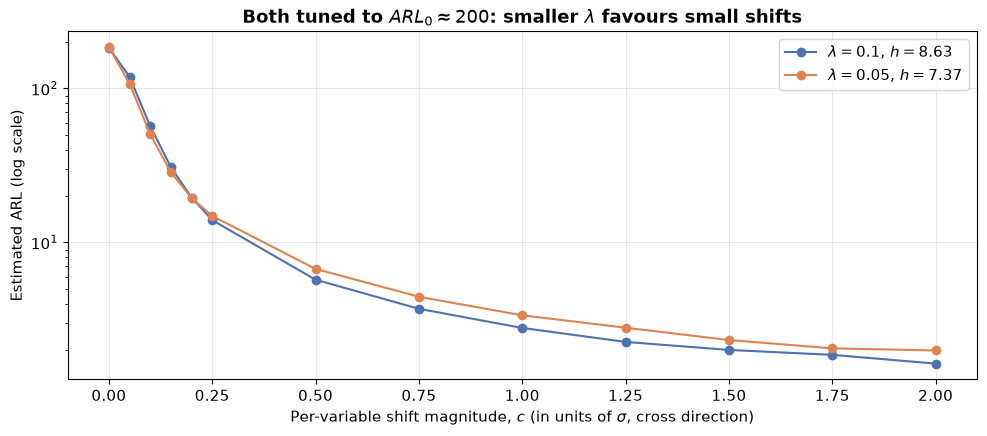

In [9]:
lam_alt = 0.05

# Re-tune h for the alternative lambda so both curves share the same ARL0 = 200 benchmark
lo, hi = chi2.ppf(0.80, df=p), chi2.ppf(0.99999, df=p)
for _ in range(10):
    mid = 0.5 * (lo + hi)
    arl0_mid, _ = estimate_arl_mewma(RNG, mu0, Sigma, lam_alt, mid, np.zeros(p), n_sims=3000, max_len=2000)
    if arl0_mid < target_arl0:
        lo = mid
    else:
        hi = mid
h_alt = 0.5 * (lo + hi)
print(f"Tuned h for lambda={lam_alt}: h = {h_alt:.3f}")

arl_lam_main = np.empty(len(magnitudes))
arl_lam_alt = np.empty(len(magnitudes))
for k, c in enumerate(magnitudes):
    arl_lam_main[k], _ = estimate_arl_mewma(RNG, mu0, Sigma, lam, h_mewma, np.array([c, -c]),
                                             n_sims=3000, max_len=500)
    arl_lam_alt[k], _ = estimate_arl_mewma(RNG, mu0, Sigma, lam_alt, h_alt, np.array([c, -c]),
                                            n_sims=3000, max_len=500)

fig, ax = plt.subplots()
ax.plot(magnitudes, arl_lam_main, marker="o", color=COL_V1, label=fr"$\lambda={lam}$, $h={h_mewma:.2f}$")
ax.plot(magnitudes, arl_lam_alt, marker="o", color=COL_V2, label=fr"$\lambda={lam_alt}$, $h={h_alt:.2f}$")
ax.set_yscale("log")
ax.set_xlabel(r"Per-variable shift magnitude, $c$ (in units of $\sigma$, cross direction)")
ax.set_ylabel("Estimated ARL (log scale)")
ax.set_title(r"Both tuned to $ARL_0\approx200$: smaller $\lambda$ favours small shifts")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Summary and key takeaways

| Concept | Formula |
|---|---|
| MEWMA statistic (equal $\lambda$) | $\mathbf{Z}_i = \lambda\mathbf{X}_i + (1-\lambda)\mathbf{Z}_{i-1}$, $\mathbf{Z}_0=\boldsymbol{\mu}_0$ |
| Mean | $E[\mathbf{Z}_i] = \boldsymbol{\mu}_0$ |
| Exact covariance | $\boldsymbol{\Sigma}_{\mathbf{Z}_i} = \left(\frac{\lambda}{2-\lambda}\right)\left[1-(1-\lambda)^{2i}\right]\boldsymbol{\Sigma}$ |
| Asymptotic covariance | $\boldsymbol{\Sigma}_{\mathbf{Z}} = \left(\frac{\lambda}{2-\lambda}\right)\boldsymbol{\Sigma}$ |
| Monitoring statistic | $T_i^2 = (\mathbf{Z}_i-\boldsymbol{\mu}_0)'\boldsymbol{\Sigma}_{\mathbf{Z}_i}^{-1}(\mathbf{Z}_i-\boldsymbol{\mu}_0)$, signal if $T_i^2 > h$ |
| Run length / ARL | Same definitions as the univariate case, applied to $T_i^2$ exceeding $h$ |

**What we learned:**

* Monitoring several correlated quality characteristics with **separate univariate charts** both inflates the overall false-alarm rate and is **blind to shifts that break the correlation** between variables, even when every individual variable still looks "normal" on its own chart.
* **Mahalanobis distance** is the right ruler for correlated data: it turns the univariate "$\pm L\sigma$ interval" into an **ellipse**, correctly stretching or squeezing depending on the correlation structure.
* The **MEWMA statistic** is the direct vector generalisation of the univariate EWMA recursion; with a single shared $\lambda$, it reduces to running the familiar scalar recursion on every variable simultaneously.
* The vector is collapsed into one number, the **Hotelling-type $T_i^2$ statistic**, monitored with a single **upper** control limit $h$ — there's no "too small" side once distance is involved.
* Although $T_i^2$ is exactly $\chi^2_p$ **at any single fixed time point** under normality, the autocorrelation between successive $\mathbf{Z}_i$'s means this chi-square quantile does **not** hand us the right $h$ for a target $ARL_0$ — exactly like the univariate case, $h$ must be tuned by **Monte Carlo simulation**.
* Perhaps the most important lesson: **two shifts of identical per-variable magnitude can have wildly different detection speed**, purely because of how they align with the correlation between variables — something no collection of separate univariate charts could ever reveal.

**Looking ahead:** this notebook used **Case K** throughout ($\boldsymbol{\mu}_0$ and $\boldsymbol{\Sigma}$ known) and a single shared smoothing constant $\lambda$. Natural next steps include estimating $\boldsymbol{\mu}_0,\boldsymbol{\Sigma}$ from a Phase I reference sample (as in the univariate notebook's own "looking ahead"), and — once a MEWMA chart signals — **decomposing** $T_i^2$ into per-variable contributions to diagnose *which* characteristic(s) drove the signal, a natural question once a joint chart flags a problem.